In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

## Đọc dữ liệu

In [2]:
df_train = pd.read_csv('D:\\DS111\\DoAnDS111\\banking_dataset\\train.csv', sep=';')
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [3]:
df_test = pd.read_csv('D:\\DS111\\DoAnDS111\\banking_dataset\\test.csv', sep=';')
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [4]:
category_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
category_columns

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [5]:
numeric_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
numeric_columns

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## Missing Values

Theo EDA-1 các cột không có missing value. Tuy nhiên có một số cột chưa giá trị đặc biết 'unknown'. Sau khi tiến hành phân tích các cột thì nhận thấy unknown chiếm tỉ lệ phần trăm rất thấp trong job, nên tiến hành xử lí giá trị unknown trong job

In [6]:
def check_unique_values(df, columns):
    
    for column in columns:
        if 'unknown' in df[column].unique():
            print(column)

check_unique_values(df_train, category_columns)   

job
education
contact
poutcome


In [7]:
for column in ['job','education','contact','poutcome']:
        print(f"Phan bo YES cua unknown trong {column}: {df_train[column][(df_train[column]=='unknown') & (df_train['y']=='yes')].count()/df_train[column][df_train['y']=='yes'].count()}")

Phan bo YES cua unknown trong job: 0.00642843637738703
Phan bo YES cua unknown trong education: 0.0476460578559274
Phan bo YES cua unknown trong contact: 0.10020797882397428
Phan bo YES cua unknown trong poutcome: 0.6401966345244848


Thay thế giá trị unknown của job dựa theo education - MODE

In [8]:
df_train[df_train['job']=='unknown']['education'].value_counts()

education
unknown      127
secondary     71
primary       51
tertiary      39
Name: count, dtype: int64

Loại bỏ các hàng có cả job và education đều là giá trị unknown

In [9]:
indexNeg = df_train[(df_train['job']=='unknown') & (df_train['education']=='unknown')].index 
df_train.drop(indexNeg, inplace=True)

In [10]:
indexNeg = df_test[(df_test['job']=='unknown') & (df_test['education']=='unknown')].index 
df_test.drop(indexNeg, inplace=True)

In [11]:
def education_job():
    for type_education in df_train['education'].unique():
        if type_education != 'unknown':
            print(f'JOB {type_education} education mode is:', df_train[df_train['education']==type_education]['job'].value_counts(normalize=True).nlargest(3))

education_job()

JOB tertiary education mode is: job
management       0.586497
technician       0.147959
self-employed    0.062627
Name: proportion, dtype: float64
JOB secondary education mode is: job
blue-collar    0.231489
technician     0.225369
admin.         0.181838
Name: proportion, dtype: float64
JOB primary education mode is: job
blue-collar    0.548533
retired        0.116041
housemaid      0.091519
Name: proportion, dtype: float64


In [12]:
df_train['job'] = np.where( ((df_train.job == 'unknown')& (df_train.education =='primary')),'blue-collar',df_train.job)
df_train['job'] = np.where( ((df_train.job == 'unknown')& (df_train.education =='tertiary')),'management',df_train.job)


df_test['job'] = np.where( ((df_test.job == 'unknown')& (df_test.education =='primary')),'blue-collar',df_test.job)
df_test['job'] = np.where( ((df_test.job == 'unknown')& (df_test.education =='tertiary')),'management',df_test.job)


def impute_job_randomly(df):
    secjobs = ['blue-collar', 'technician', 'admin.']
    
    condition = (df['job'] == 'unknown') & (df['education'] == 'secondary')
    
    impute_indices = df.loc[condition].index
    
    random_choices = np.random.choice(secjobs, size=len(impute_indices))
    
    df.loc[impute_indices, 'job'] = random_choices
    
    return df

df_train = impute_job_randomly(df_train)
df_test = impute_job_randomly(df_test)

Thay thế giá trị unknown của education dựa theo job - MODE 

In [13]:
df_train[df_train['education']=='unknown']['job'].value_counts()

job
blue-collar      454
technician       242
management       242
admin.           171
student          163
services         150
retired          119
entrepreneur      76
housemaid         45
self-employed     39
unemployed        29
Name: count, dtype: int64

In [14]:
def job_education():
    for name_job in df_train['job'].unique():
        if name_job != 'unknown':
            print(f'JOB {name_job} education mode is:', df_train[df_train['job']==name_job]['education'].value_counts(normalize=True).nlargest(2))

job_education()

JOB management education mode is: education
tertiary     0.825524
secondary    0.118037
Name: proportion, dtype: float64
JOB technician education mode is: education
secondary    0.68932
tertiary     0.25820
Name: proportion, dtype: float64
JOB entrepreneur education mode is: education
tertiary     0.461332
secondary    0.364492
Name: proportion, dtype: float64
JOB blue-collar education mode is: education
secondary    0.549750
primary      0.388713
Name: proportion, dtype: float64
JOB retired education mode is: education
secondary    0.434629
primary      0.351148
Name: proportion, dtype: float64
JOB admin. education mode is: education
secondary    0.816958
tertiary     0.109979
Name: proportion, dtype: float64
JOB services education mode is: education
secondary    0.832210
primary      0.083052
Name: proportion, dtype: float64
JOB self-employed education mode is: education
tertiary     0.527549
secondary    0.365421
Name: proportion, dtype: float64
JOB unemployed education mode is: edu

In [15]:
# Modes

s=['blue-collar', 'technician', 'admin.' ,'student', 'education', 'retired', 'services' ,'unemployed']
t=['management','entrepreneur','self-employed']

# TRAIN DATA

for job in s:
    df_train['education'] = np.where( ((df_train.education == 'unknown')& (df_train.job ==job)),'secondary',df_train.education)
    
for job in t:
    df_train['education'] = np.where( ((df_train.education == 'unknown')& (df_train.job ==job)),'tertiary',df_train.education)
    
df_train['education'] = np.where( ((df_train.education == 'unknown')& (df_train.job =='housemaid')),'primary',df_train.education)


#TEST DATA

for job in s:
    df_test['education'] = np.where( ((df_test.education == 'unknown')& (df_test.job ==job)),'secondary',df_test.education)
    
for job in t:
    df_test['education'] = np.where( ((df_test.education == 'unknown')& (df_test.job ==job)),'tertiary',df_test.education)
    
df_test['education'] = np.where( ((df_test.education == 'unknown')& (df_test.job =='housemaid')),'primary',df_test.education)

Thay giá trị của unknown của contact

In [16]:
df_train['contact'].value_counts()

contact
cellular     29236
unknown      12966
telephone     2882
Name: count, dtype: int64

In [17]:
# MODE
df_train['contact'] = np.where( (df_train.contact == 'unknown'),'cellular',df_train.contact)

df_test['contact'] = np.where( (df_test.contact == 'unknown'),'cellular',df_test.contact)

Thay giá trị của unknown của poutcome

In [18]:
round(df_train['poutcome'].value_counts(normalize=True)*100,2)

poutcome
unknown    81.72
failure    10.86
other       4.08
success     3.34
Name: proportion, dtype: float64

## OUTLIER

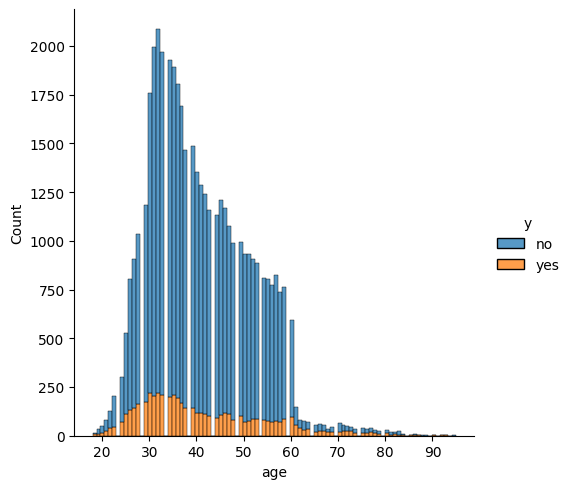

In [19]:
sns.displot(data=df_train, x=df_train['age'], hue=df_train['y'], multiple='stack')

Theo EDA, outlier của age là các giá trị > 70, nhưng theo biểu đồ trên thì khách hàng > 70 tuổi chiếm số lượng thấp so với tổng số khách hàng nhưng có tỉ lệ khách hàng có biến mục tiêu ‘y’ = yes nhiều nhất
=>	Nên xử lí outlier này bằng Binning Group Age

In [20]:
def create_age_group(df):
    
    conditions = [
        ((df['age'] >= 0) & (df['age'] <= 29)),
        ((df['age'] >= 30) & (df['age'] <= 39)),
        ((df['age'] >= 40) & (df['age'] <= 49)),
        ((df['age'] >= 50) & (df['age'] <= 59)),
        ((df['age'] >= 60) & (df['age'] <= 69)),
        ((df['age'] >= 70) & (df['age'] <= 100))
    ]
    
    values = ['U30', 'U40', 'U50', 'U60', 'U70', 'U100']

    df['age_group'] = np.select(conditions, values, default='Other')
    return df

df_train = create_age_group(df_train)
df_test = create_age_group(df_test)

Biến balance được xử lý bằng hai kỹ thuật kết hợp:
1. Shifted Log Transformation ($\ln(\text{balance} + C)$) được áp dụng để giảm độ lệch mạnh và ảnh hưởng của các giá trị ngoại lệ (Outlier), trong khi vẫn bảo toàn tính liên tục của dữ liệu.
2. Tạo biến chỉ báo balance_flag (Binary Flag) để mã hóa rõ ràng thông tin về tình trạng thấu chi/nợ, giúp mô hình học dễ dàng hơn về rủi ro của nhóm khách hàng này.

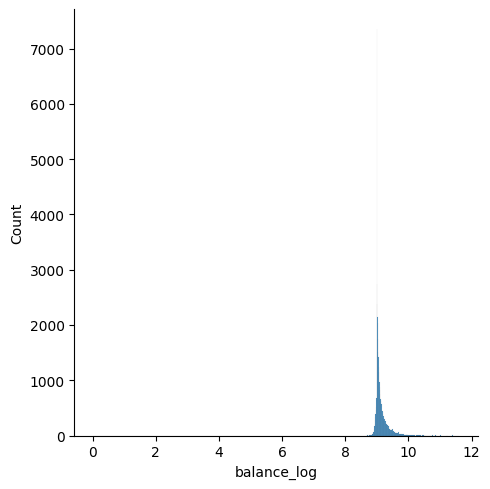

In [21]:
min_balance_train = df_train['balance'].min()
if min_balance_train < 0:
    C = np.abs(min_balance_train) + 1
else:
    C = 1

df_train['balance_log'] = np.log(df_train['balance'] + C)

df_test['balance_log'] = np.log(df_test['balance'] + C)


df_train['balance_flag'] = (df_train['balance'] < 0).astype(int)

df_test['balance_flag'] = (df_test['balance'] < 0).astype(int)

sns.displot(df_train['balance_log'])


Tương tự với duration, previous, campaign, pdays

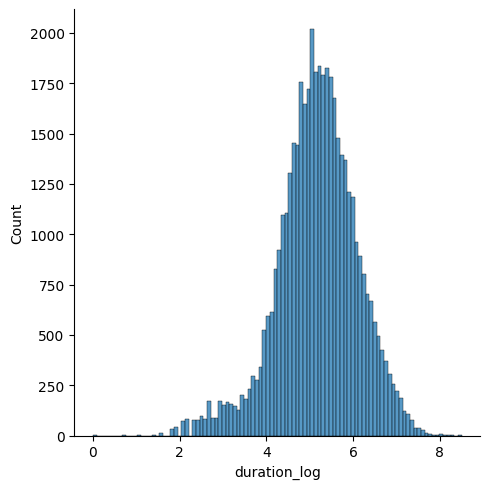

In [22]:
df_train['duration_log'] = np.log1p(df_train['duration'])

df_test['duration_log'] = np.log1p(df_test['duration'])

sns.displot(df_train['duration_log'], bins=100)

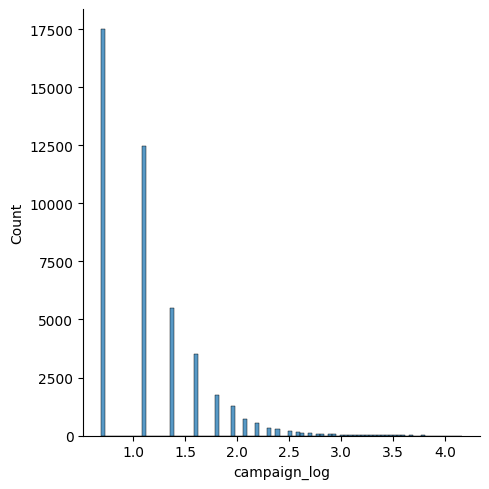

In [23]:
df_train['campaign_log'] = np.log1p(df_train['campaign'])

df_test['campaign_log'] = np.log1p(df_test['campaign'])

sns.displot(df_train['campaign_log'])

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


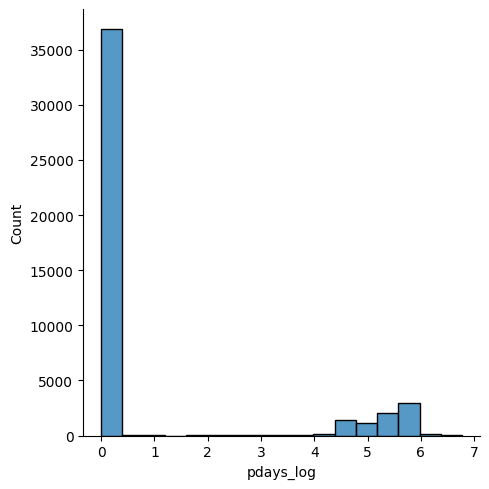

In [24]:
df_train['pdays_contacted'] = np.where(df_train['pdays'] > -1, 1, 0)
df_test['pdays_contacted'] = np.where(df_test['pdays'] > -1, 1, 0)

df_train['pdays_log'] = np.where(df_train['pdays'] > -1, np.log1p(df_train['pdays']), 0)

df_test['pdays_log'] = np.where(df_test['pdays'] > -1, np.log1p(df_test['pdays']), 0)

sns.displot(df_train['pdays_log'])

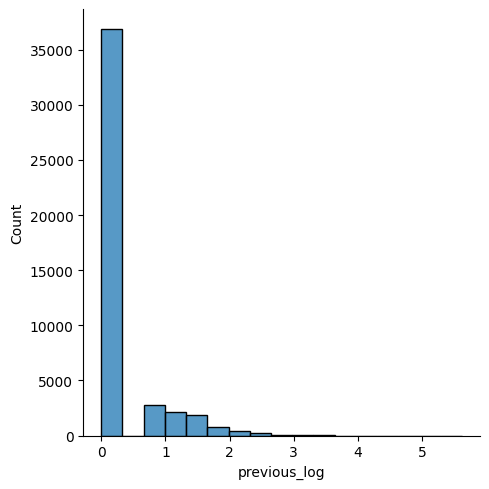

In [25]:
df_train['previous_log'] = np.where(df_train['previous'] > 0, np.log1p(df_train['previous']), 0)

df_test['previous_log'] = np.where(df_test['previous'] > 0, np.log1p(df_test['previous']), 0)

sns.displot(df_train['previous_log'])

## StandardScaler

In [26]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45084 entries, 0 to 45210
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45084 non-null  int64  
 1   job              45084 non-null  object 
 2   marital          45084 non-null  object 
 3   education        45084 non-null  object 
 4   default          45084 non-null  object 
 5   balance          45084 non-null  int64  
 6   housing          45084 non-null  object 
 7   loan             45084 non-null  object 
 8   contact          45084 non-null  object 
 9   day              45084 non-null  int64  
 10  month            45084 non-null  object 
 11  duration         45084 non-null  int64  
 12  campaign         45084 non-null  int64  
 13  pdays            45084 non-null  int64  
 14  previous         45084 non-null  int64  
 15  poutcome         45084 non-null  object 
 16  y                45084 non-null  object 
 17  age_group        

In [27]:
%pip install scikit-learn 
from sklearn.preprocessing import StandardScaler

numerical_features = [
    'duration_log',            
    'campaign_log',     
    'balance_log',      
    'pdays_log',        
    'previous_log'      
]

scaler = StandardScaler()

scaler.fit(df_train[numerical_features])


X_train_scaled_array = scaler.transform(df_train[numerical_features])
X_test_scaled_array = scaler.transform(df_test[numerical_features])

df_train[numerical_features] = X_train_scaled_array
df_test[numerical_features] = X_test_scaled_array

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Encoding

In [28]:
df_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group', 'balance_log', 'balance_flag',
       'duration_log', 'campaign_log', 'pdays_contacted', 'pdays_log',
       'previous_log'],
      dtype='object')

In [29]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

ordinal_features = 'education'

education_mapping = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}

df_train[ordinal_features] = df_train[ordinal_features].replace(education_mapping)
df_test[ordinal_features] = df_test[ordinal_features].replace(education_mapping)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3408\4220200080.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[ordinal_features] = df_train[ordinal_features].replace(education_mapping)
C:\Users\Admin\AppData\Local\Temp\ipykernel_3408\4220200080.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[ordinal_features] = df_test[ordinal_features].replace(education_mapping)


In [30]:
le_features = [
    'default', 'housing', 'loan', 'balance_flag', 'pdays_contacted',
    'job', 'marital', 'contact', 'poutcome', 'age_group'   
    ]
for col in le_features:
    le = LabelEncoder()
    
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    
    df_test[col] = df_test[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

In [31]:
# CYCLICAL ENCODING

MAX_DAY = 31
encoded_dfs = [] 

df_train['day'] = np.sin(2 * np.pi * df_train['day'] / MAX_DAY)
df_train['day'] = np.cos(2 * np.pi * df_train['day'] / MAX_DAY)

df_test['day'] = np.sin(2 * np.pi * df_test['day'] / MAX_DAY)
df_test['day'] = np.cos(2 * np.pi * df_test['day'] / MAX_DAY)

month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

df_train['month'] = df_train['month'].map(month_mapping)
df_test['month'] = df_test['month'].map(month_mapping)

MAX_MONTH = 12

df_train['month'] = np.sin(2 * np.pi * df_train['month'] / MAX_MONTH)
df_train['month'] = np.cos(2 * np.pi * df_train['month'] / MAX_MONTH)

df_test['month'] = np.sin(2 * np.pi * df_test['month'] / MAX_MONTH)
df_test['month'] = np.cos(2 * np.pi * df_test['month'] / MAX_MONTH)

In [32]:
target_mapping = {'no': 0, 'yes': 1}

df_train['y'] = df_train['y'].map(target_mapping)
df_test['y'] = df_test['y'].map(target_mapping)

In [33]:
df_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group', 'balance_log', 'balance_flag',
       'duration_log', 'campaign_log', 'pdays_contacted', 'pdays_log',
       'previous_log'],
      dtype='object')

## Feature Selection

In [34]:
# Danh sách tất cả các cột gốc, cột rò rỉ, và cột trung gian cần DROP
columns_to_drop_final = [
    'age',
    'balance', 
    'campaign',
    'duration',
    'pdays', 
    'previous',
]

df_train = df_train.drop(columns=columns_to_drop_final, errors='ignore')
df_test = df_test.drop(columns=columns_to_drop_final, errors='ignore')


In [35]:
TARGET_COL = 'y'

X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL]

X_test = df_test.drop(columns=[TARGET_COL])
y_test = df_test[TARGET_COL]

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_test: {y_test.shape}")

print("\n✅ Việc phân chia X_train, y_train, X_test, y_test đã hoàn tất.")

Kích thước X_train: (45084, 18)
Kích thước y_train: (45084,)
Kích thước X_test: (4506, 18)
Kích thước y_test: (4506,)

✅ Việc phân chia X_train, y_train, X_test, y_test đã hoàn tất.


In [36]:
OUTPUT_DIR = 'D:\DS111\DoAnDS111\processed_data' 

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train.to_csv(os.path.join(OUTPUT_DIR, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(OUTPUT_DIR, 'X_test.csv'), index=False)

y_train_df = y_train.to_frame(name='y')
y_test_df = y_test.to_frame(name='y')

y_train_df.to_csv(os.path.join(OUTPUT_DIR, 'y_train.csv'), index=False)
y_test_df.to_csv(os.path.join(OUTPUT_DIR, 'y_test.csv'), index=False)